In [697]:
import pandas as pd
import numpy as np
import scipy.stats as stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [698]:
df = pd.read_csv('/content/bigmart.csv')
df.sample(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
2000,FDJ50,8.645,Low Fat,0.021582,Canned,53.3982,OUT035,2004,Small,Tier 2,Supermarket Type1,1209.7586
6964,FDH32,12.800,Low Fat,0.075997,Fruits and Vegetables,97.1410,OUT013,1987,High,Tier 3,Supermarket Type1,2799.6890
1394,FDV34,10.695,Regular,0.011449,Snack Foods,72.9038,OUT045,2002,NaN,Tier 2,Supermarket Type1,1034.6532
7620,DRI51,NaN,Low Fat,0.042037,Dairy,172.6764,OUT027,1985,Medium,Tier 3,Supermarket Type3,6183.9504
2675,NCJ31,NaN,LF,0.181769,Others,240.6196,OUT027,1985,Medium,Tier 3,Supermarket Type3,4579.3724
2331,FDT07,5.820,reg,0.000000,Fruits and Vegetables,256.6330,OUT049,1999,Medium,Tier 1,Supermarket Type1,2050.6640
4996,DRL60,8.520,Low Fat,0.027059,Soft Drinks,153.3682,OUT046,1997,Small,Tier 1,Supermarket Type1,914.8092
2249,DRE15,13.350,Low Fat,0.000000,Dairy,77.6012,OUT046,1997,Small,Tier 1,Supermarket Type1,986.7156
2785,FDV45,16.750,Low Fat,0.045139,Snack Foods,187.9556,OUT045,2002,NaN,Tier 2,Supermarket Type1,2816.3340
2932,FDF20,12.850,Low Fat,0.033272,Fruits and Vegetables,196.5768,OUT049,1999,Medium,Tier 1,Supermarket Type1,5715.2272


In [699]:
df.shape

(8523, 12)

In [700]:
fat_content = df['Item_Fat_Content']
fat_content.value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [701]:
df.drop_duplicates(inplace=True)

In [702]:
fat_values = fat_content.value_counts()
fat_content.isna().sum()

np.int64(0)

In [703]:
fat_values

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [704]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})
fat_values = df['Item_Fat_Content'].value_counts()

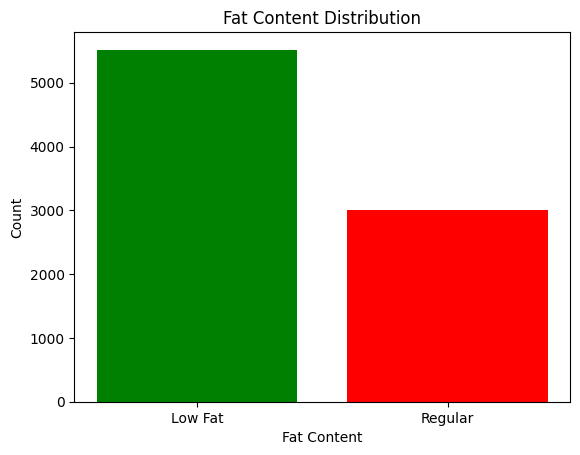

In [705]:
plt.bar(fat_values.index, fat_values.values, color=['green', 'red'])
plt.xlabel('Fat Content')
plt.ylabel('Count')
plt.title('Fat Content Distribution')
plt.show()

In [706]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [707]:
weight = df['Item_Weight']
weight.isna().sum()

np.int64(1463)

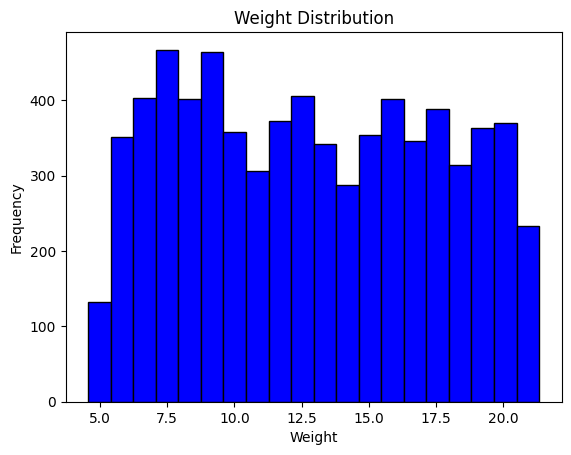

In [708]:
plt.hist(weight, bins=20, color='blue', edgecolor='black')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.title('Weight Distribution')
plt.show()

In [709]:
weight.skew()

np.float64(0.0824262091221237)

In [710]:
print(weight.mean())
print(weight.median())

12.857645184135976
12.6


/tmp/ipykernel_2292/772163729.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(weight)


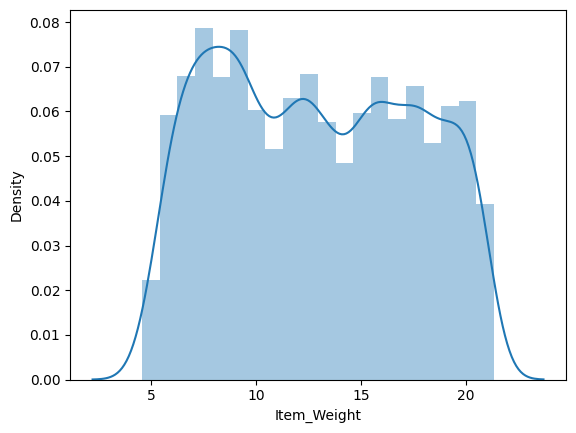

In [711]:
sns.distplot(weight)
plt.show()

In [712]:
from numpy._core.defchararray import lower
q1 = np.percentile(weight, 25)
q3 = np.percentile(weight, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = weight[(weight < lower_bound) | (weight > upper_bound)]
outliers

,Item_Weight


/tmp/ipykernel_2292/1449834923.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(weight)


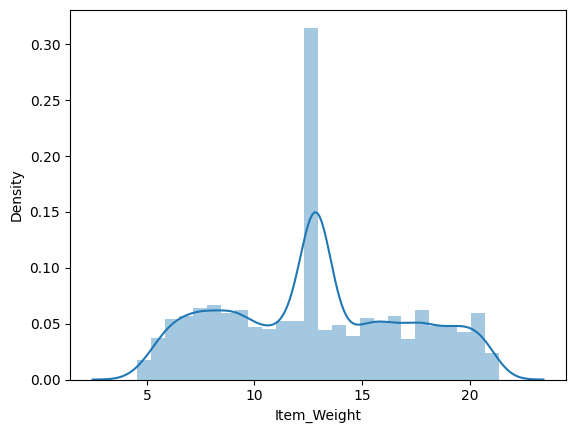

In [713]:
df['Item_Weight'].fillna(weight.mean(), inplace=True)
sns.distplot(weight)
plt.show()

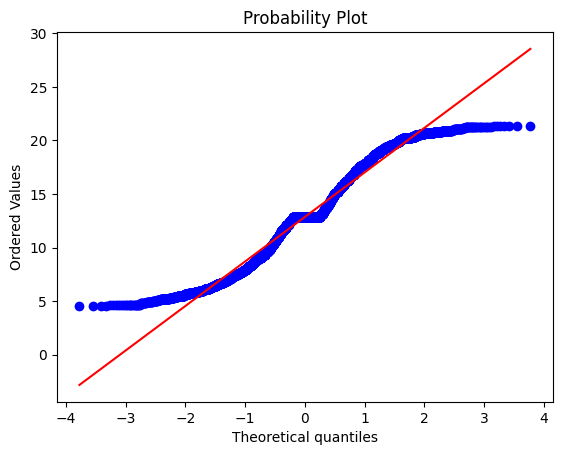

In [714]:
stats.probplot(weight, dist='norm', plot=plt)
plt.show()

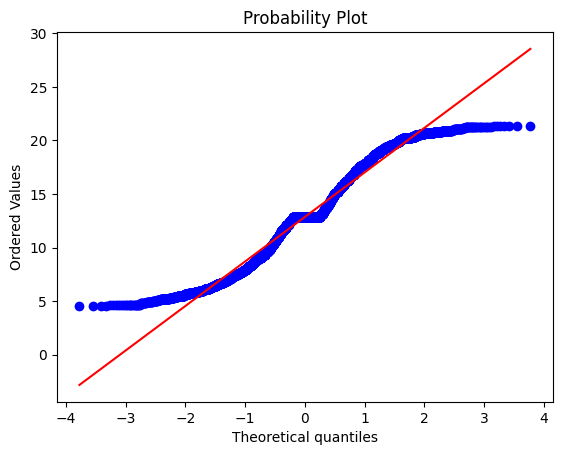

In [715]:
df['Item_Weight'] = (
    df.groupby('Item_Identifier')['Item_Weight']
      .transform(lambda x: x.fillna(x.mean()))
)
weight = df['Item_Weight']
stats.probplot(weight, dist='norm', plot=plt)
plt.show()

/tmp/ipykernel_2292/1998283115.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Item_Weight'])


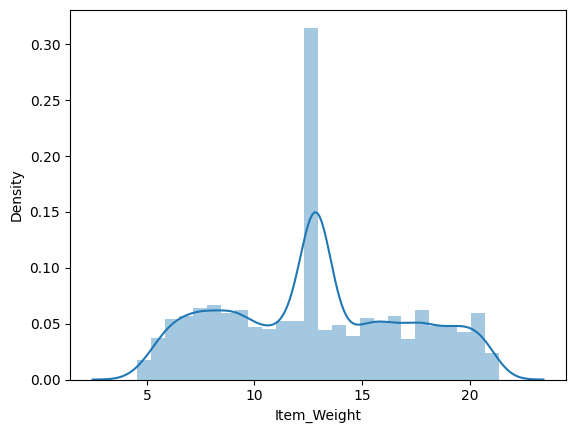

In [716]:
sns.distplot(df['Item_Weight'])
plt.show()

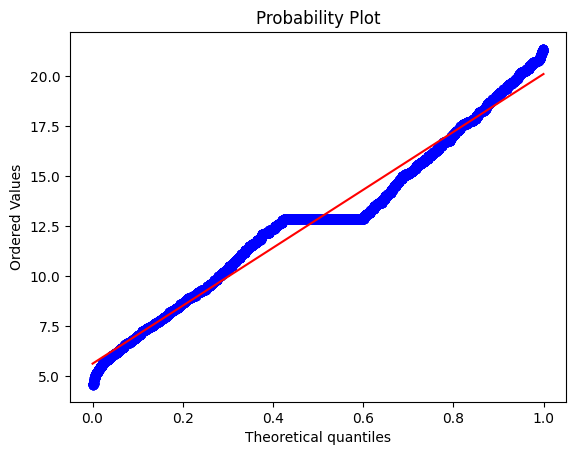

In [717]:
stats.probplot(df['Item_Weight'], dist='uniform', plot=plt)
plt.show()

In [718]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [719]:
visibility = df['Item_Visibility']
visibility.isna().sum()

np.int64(0)

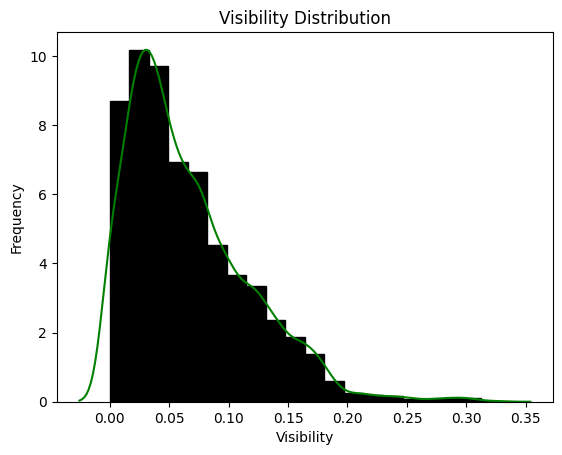

In [720]:
plt.hist(visibility, bins=20, color='black', edgecolor='black', density=True)
sns.kdeplot(visibility, color='green')
plt.xlabel('Visibility')
plt.ylabel('Frequency')
plt.title('Visibility Distribution')
plt.show()

In [721]:
visibility.skew()

np.float64(1.1670905496918396)

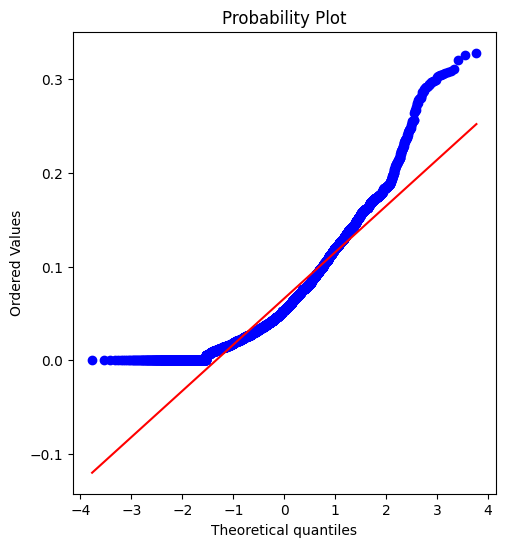

In [722]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
stats.probplot(visibility, dist='norm', plot=plt)
plt.show()

In [723]:
params = stats.pareto.fit(visibility.apply(lambda x: x+1), floc=0)
dist = stats.pareto(b=params[0], scale=params[2])

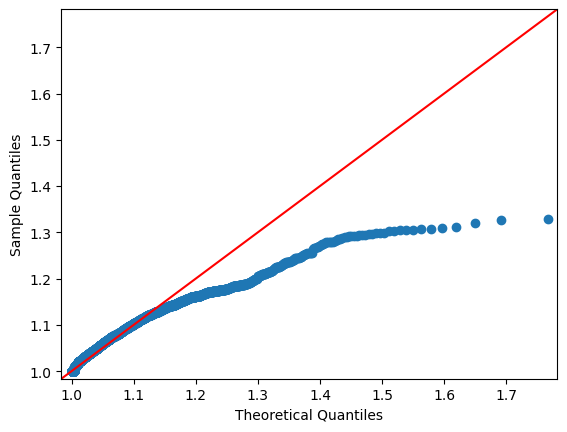

In [724]:
import statsmodels.api as sm
fig = sm.qqplot(visibility.apply(lambda x: x+1), dist=dist, line='45')
plt.show()

In [725]:
print(visibility.mean())
print(visibility.median())

0.06613202877895108
0.053930934


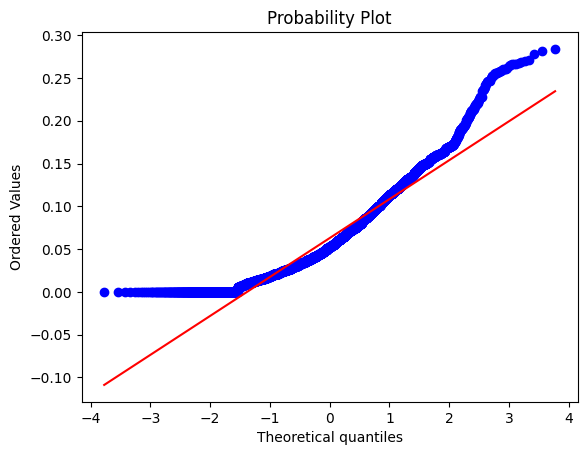

In [726]:
from sklearn.preprocessing import FunctionTransformer

ftr = FunctionTransformer(func=np.log1p)
transformed_visible = ftr.fit_transform(visibility)

stats.probplot(transformed_visible, dist='norm', plot=plt)
plt.show()

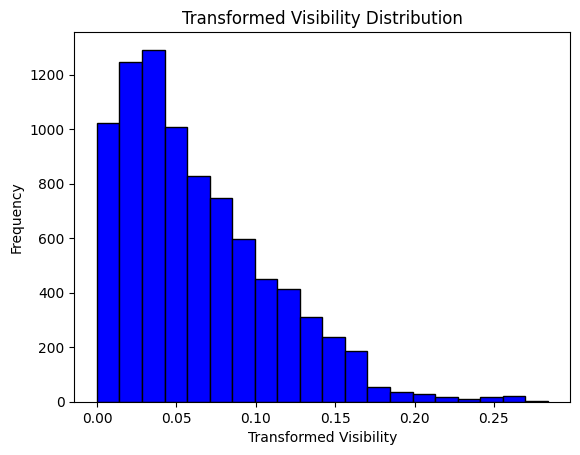

In [727]:
plt.hist(transformed_visible, bins=20, color='blue', edgecolor='black')
plt.xlabel('Transformed Visibility')
plt.ylabel('Frequency')
plt.title('Transformed Visibility Distribution')
plt.show()

In [728]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

x = visibility.values.reshape(-1, 1)
if (x <= 0).any():
    x = x - x.min() + 0.001

pt = PowerTransformer(method='box-cox')
transformed_visible = pt.fit_transform(x)


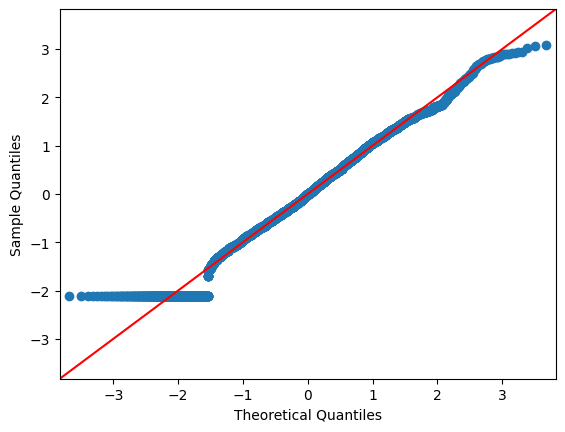

In [729]:
sm.qqplot(transformed_visible.flatten(), dist=stats.norm, line='45')
plt.show()
df['Item_Visibility'] = transformed_visible.flatten()

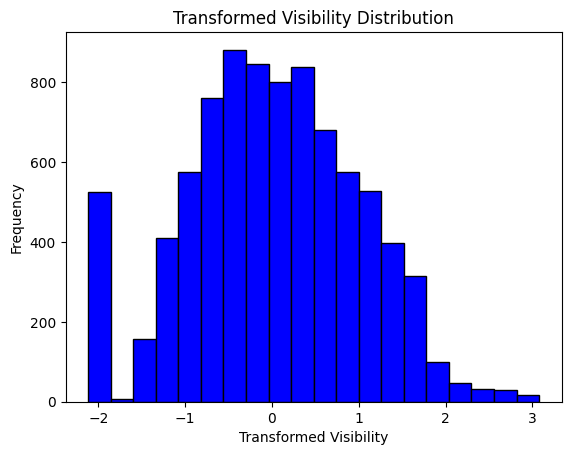

In [730]:
plt.hist(transformed_visible, bins=20, color='blue', edgecolor='black')
plt.xlabel('Transformed Visibility')
plt.ylabel('Frequency')
plt.title('Transformed Visibility Distribution')
plt.show()

/tmp/ipykernel_2292/4156049.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(transformed_visible)


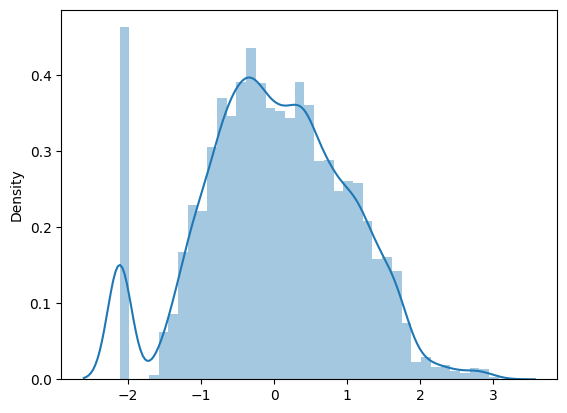

In [731]:
sns.distplot(transformed_visible)
plt.show()

In [732]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [733]:
pt = PowerTransformer(method='yeo-johnson')
x_yj = pt.fit_transform(visibility.values.reshape(-1,1))

/tmp/ipykernel_2292/3309825372.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_yj)


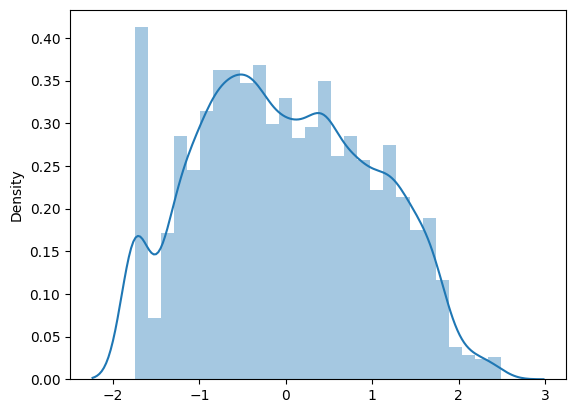

In [734]:
sns.distplot(x_yj)
plt.show()

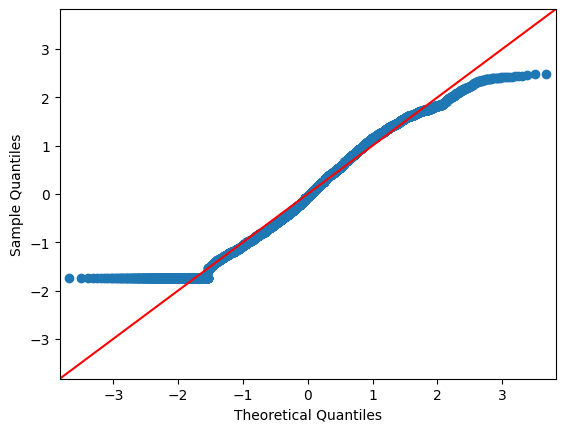

In [735]:
sm.qqplot(x_yj.flatten(), dist=stats.norm, line='45')
plt.show()

In [736]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [737]:
items = df['Item_Type']
items.value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [738]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
encoded_items = ohe.fit_transform(items.values.reshape(-1, 1))
enode_df = pd.DataFrame(encoded_items, columns=ohe.get_feature_names_out(['Item_Type']))
enode_df.head()

,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [739]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

encoded_items = ohe.fit_transform(df[['Item_Type']])

encoded_df = pd.DataFrame(
    encoded_items,
    columns=ohe.get_feature_names_out(['Item_Type']),
    index=df.index
)

df = pd.concat(
    [df.drop('Item_Type', axis=1), encoded_df],
    axis=1
)

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,FDA15,9.30,Low Fat,-1.035068,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,DRC01,5.92,Regular,-0.914060,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,FDN15,17.50,Low Fat,-1.007343,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,FDX07,19.20,Regular,-2.117138,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NCD19,8.93,Low Fat,-2.117138,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [740]:
from sklearn.preprocessing import OneHotEncoder

encoded_fat = ohe.fit_transform(df[['Item_Fat_Content']])

encoded_fat = pd.DataFrame(
    encoded_fat,
    columns=ohe.get_feature_names_out(['Item_Fat_Content']),
    index=df.index
)

df = pd.concat(
    [df.drop('Item_Fat_Content', axis=1), encoded_fat],
    axis=1
)

df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular
0,FDA15,9.30,-1.035068,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,DRC01,5.92,-0.914060,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,FDN15,17.50,-1.007343,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,FDX07,19.20,-2.117138,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,NCD19,8.93,-2.117138,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [741]:
curr_year = 2026
df['Outlet_Age'] = curr_year - df['Outlet_Establishment_Year']

df.drop('Outlet_Establishment_Year', axis=1, inplace=True)
df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age
0,FDA15,9.30,-1.035068,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
1,DRC01,5.92,-0.914060,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17
2,FDN15,17.50,-1.007343,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
3,FDX07,19.20,-2.117138,182.0950,OUT010,NaN,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28
4,NCD19,8.93,-2.117138,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39


<Axes: xlabel='Item_MRP', ylabel='Count'>

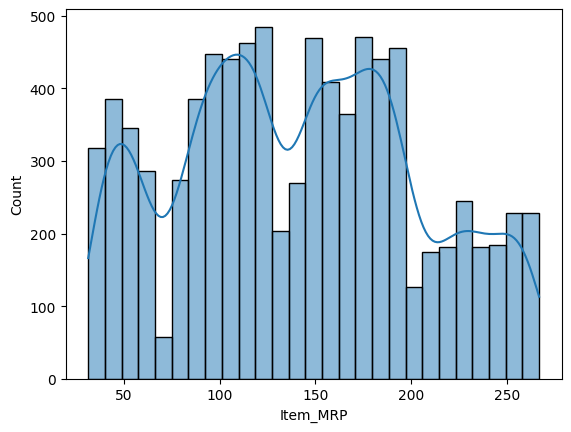

In [742]:
sns.histplot(df['Item_MRP'], kde=True)

In [743]:
print(df['Item_MRP'].skew())

0.1272022683110526


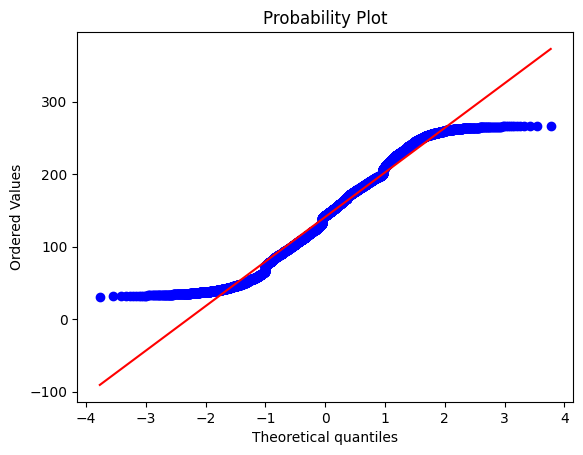

In [744]:
stats.probplot(df['Item_MRP'], dist='norm', plot=plt)
plt.show()

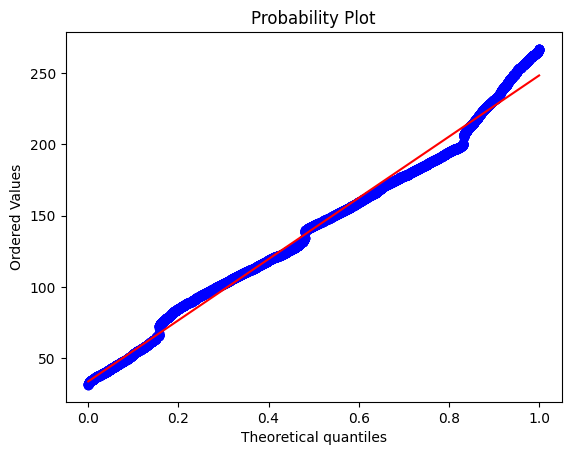

In [745]:
stats.probplot(df['Item_MRP'], dist='uniform', plot=plt)
plt.show()

In [746]:
df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age
0,FDA15,9.30,-1.035068,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
1,DRC01,5.92,-0.914060,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17
2,FDN15,17.50,-1.007343,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
3,FDX07,19.20,-2.117138,182.0950,OUT010,NaN,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28
4,NCD19,8.93,-2.117138,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39


In [747]:
df['Outlet_Size'].isna().sum()

np.int64(2410)

In [748]:
pd.crosstab(df['Outlet_Type'], df['Outlet_Size'])

Outlet_Size,High,Medium,Small
Outlet_Type,,,
Grocery Store,0,0,528
Supermarket Type1,932,930,1860
Supermarket Type2,0,928,0
Supermarket Type3,0,935,0


In [749]:
df['Outlet_Size'] = (
    df.groupby('Outlet_Type')['Outlet_Size']
      .transform(lambda x: x.fillna(x.mode().iloc[0]))
)

In [750]:
df['Outlet_Size'].isna().sum()

np.int64(0)

In [751]:
df

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age
0,FDA15,9.300,-1.035068,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
1,DRC01,5.920,-0.914060,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17
2,FDN15,17.500,-1.007343,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
3,FDX07,19.200,-2.117138,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28
4,NCD19,8.930,-2.117138,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0.051571,214.5218,OUT013,High,Tier 3,Supermarket Type1,2778.3834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,39
8519,FDS36,8.380,-0.154123,108.1570,OUT045,Small,Tier 2,Supermarket Type1,549.2850,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,24
8520,NCJ29,10.600,-0.435681,85.1224,OUT035,Small,Tier 2,Supermarket Type1,1193.1136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,22
8521,FDN46,7.210,1.376163,103.1332,OUT018,Medium,Tier 3,Supermarket Type2,1845.5976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,17


In [752]:
mapping = {
    'Small': 1,
    'Medium': 2,
    'High': 3
}

df['Outlet_Size'] = df['Outlet_Size'].map(mapping)
df

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age
0,FDA15,9.300,-1.035068,249.8092,OUT049,2,Tier 1,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
1,DRC01,5.920,-0.914060,48.2692,OUT018,2,Tier 3,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17
2,FDN15,17.500,-1.007343,141.6180,OUT049,2,Tier 1,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27
3,FDX07,19.200,-2.117138,182.0950,OUT010,1,Tier 3,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28
4,NCD19,8.930,-2.117138,53.8614,OUT013,3,Tier 3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0.051571,214.5218,OUT013,3,Tier 3,Supermarket Type1,2778.3834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,39
8519,FDS36,8.380,-0.154123,108.1570,OUT045,1,Tier 2,Supermarket Type1,549.2850,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,24
8520,NCJ29,10.600,-0.435681,85.1224,OUT035,1,Tier 2,Supermarket Type1,1193.1136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,22
8521,FDN46,7.210,1.376163,103.1332,OUT018,2,Tier 3,Supermarket Type2,1845.5976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,17


In [753]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

encoded_tier = ohe.fit_transform(df[['Outlet_Location_Type']])

encoded_df = pd.DataFrame(
    encoded_tier,
    columns=ohe.get_feature_names_out(['Outlet_Location_Type']),
    index=df.index
)

df = pd.concat(
    [df.drop('Outlet_Location_Type', axis=1), encoded_df],
    axis=1
)

df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3
0,FDA15,9.30,-1.035068,249.8092,OUT049,2,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0
1,DRC01,5.92,-0.914060,48.2692,OUT018,2,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17,0.0,0.0,1.0
2,FDN15,17.50,-1.007343,141.6180,OUT049,2,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0
3,FDX07,19.20,-2.117138,182.0950,OUT010,1,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28,0.0,0.0,1.0
4,NCD19,8.93,-2.117138,53.8614,OUT013,3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39,0.0,0.0,1.0


In [754]:
df['Outlet_Identifier'].unique()

array(['OUT049', 'OUT018', 'OUT010', 'OUT013', 'OUT027', 'OUT045',
       'OUT017', 'OUT046', 'OUT035', 'OUT019'], dtype=object)

In [755]:
encode_identifiers = ohe.fit_transform(df[['Outlet_Identifier']])

encoded_df = pd.DataFrame(
    encode_identifiers,
    columns=ohe.get_feature_names_out(['Outlet_Identifier']),
    index=df.index)

df = pd.concat([df.drop('Outlet_Identifier', axis=1), encoded_df], axis=1)
df

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Size,Outlet_Type,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049
0,FDA15,9.300,-1.035068,249.8092,2,Supermarket Type1,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,DRC01,5.920,-0.914060,48.2692,2,Supermarket Type2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FDN15,17.500,-1.007343,141.6180,2,Supermarket Type1,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,FDX07,19.200,-2.117138,182.0950,1,Grocery Store,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,NCD19,8.930,-2.117138,53.8614,3,Supermarket Type1,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,0.051571,214.5218,3,Supermarket Type1,2778.3834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,39,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8519,FDS36,8.380,-0.154123,108.1570,1,Supermarket Type1,549.2850,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,24,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8520,NCJ29,10.600,-0.435681,85.1224,1,Supermarket Type1,1193.1136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,22,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8521,FDN46,7.210,1.376163,103.1332,2,Supermarket Type2,1845.5976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,17,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [756]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Size', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Type_Baking Goods', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods',
       'Item_Fat_Content_Low Fat', 'Item_Fat_Content_Regular', 'Outlet_Age',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Identifier_OUT010',
       'Outlet_Identifier_OUT013', 'Outlet_Identifier_OUT017',
       'Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT019',
       'Outlet_Identifier_OUT027', 'Outlet_Identifier_OUT035',
       'Outlet_Identifier_OUT045', 'Outlet

In [757]:
ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[['Outlet_Type']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Outlet_Type']),
    index=df.index
)

df = pd.concat([df.drop(columns='Outlet_Type'), encoded_df], axis=1)

In [758]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Size', 'Item_Outlet_Sales', 'Item_Type_Baking Goods',
       'Item_Type_Breads', 'Item_Type_Breakfast', 'Item_Type_Canned',
       'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods',
       'Item_Fat_Content_Low Fat', 'Item_Fat_Content_Regular', 'Outlet_Age',
       'Outlet_Location_Type_Tier 1', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Identifier_OUT010',
       'Outlet_Identifier_OUT013', 'Outlet_Identifier_OUT017',
       'Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT019',
       'Outlet_Identifier_OUT027', 'Outlet_Identifier_OUT035',
       'Outlet_Identifier_OUT045', 'Outlet_Identifier_OUT

In [759]:
df.head()

,Item_Identifier,Item_Weight,Item_Visibility,Item_MRP,Outlet_Size,Item_Outlet_Sales,Item_Type_Baking Goods,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Outlet_Age,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,FDA15,9.30,-1.035068,249.8092,2,3735.1380,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,DRC01,5.92,-0.914060,48.2692,2,443.4228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,17,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,FDN15,17.50,-1.007343,141.6180,2,2097.2700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,27,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,FDX07,19.20,-2.117138,182.0950,1,732.3800,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,28,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,NCD19,8.93,-2.117138,53.8614,3,994.7052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,39,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [760]:
df.drop('Item_Identifier', axis=1, inplace=True)

In [761]:
df.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Size',
       'Item_Outlet_Sales', 'Item_Type_Baking Goods', 'Item_Type_Breads',
       'Item_Type_Breakfast', 'Item_Type_Canned', 'Item_Type_Dairy',
       'Item_Type_Frozen Foods', 'Item_Type_Fruits and Vegetables',
       'Item_Type_Hard Drinks', 'Item_Type_Health and Hygiene',
       'Item_Type_Household', 'Item_Type_Meat', 'Item_Type_Others',
       'Item_Type_Seafood', 'Item_Type_Snack Foods', 'Item_Type_Soft Drinks',
       'Item_Type_Starchy Foods', 'Item_Fat_Content_Low Fat',
       'Item_Fat_Content_Regular', 'Outlet_Age', 'Outlet_Location_Type_Tier 1',
       'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3',
       'Outlet_Identifier_OUT010', 'Outlet_Identifier_OUT013',
       'Outlet_Identifier_OUT017', 'Outlet_Identifier_OUT018',
       'Outlet_Identifier_OUT019', 'Outlet_Identifier_OUT027',
       'Outlet_Identifier_OUT035', 'Outlet_Identifier_OUT045',
       'Outlet_Identifier_OUT046', 'Outlet_Ident

In [762]:
df.isna().sum()

,0
Item_Weight,0
Item_Visibility,0
Item_MRP,0
Outlet_Size,0
Item_Outlet_Sales,0
Item_Type_Baking Goods,0
Item_Type_Breads,0
Item_Type_Breakfast,0
Item_Type_Canned,0
Item_Type_Dairy,0


In [763]:
df.dtypes

,0
Item_Weight,float64
Item_Visibility,float64
Item_MRP,float64
Outlet_Size,int64
Item_Outlet_Sales,float64
Item_Type_Baking Goods,float64
Item_Type_Breads,float64
Item_Type_Breakfast,float64
Item_Type_Canned,float64
Item_Type_Dairy,float64


In [764]:
X = df.drop('Item_Outlet_Sales', axis=1)
Y = df['Item_Outlet_Sales']

In [765]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [766]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor

m1 = LinearRegression()
m2 = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
m1.fit(X_train, Y_train)

LinearRegression()

In [767]:
m2.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

In [771]:
from sklearn.metrics import mean_absolute_error
y1_pred = m1.predict(X_test)
y2_pred = m2.predict(X_test)

print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(Y_test, y1_pred))
print("R2 Score:", r2_score(Y_test, y1_pred))
print("RMSE Score", np.sqrt(mean_squared_error(Y_test, y1_pred)))
print("Mean Absolute Error", mean_absolute_error(Y_test, y1_pred))

Linear Regression Metrics:
MSE: 1144735.7932554095
R2 Score: 0.5788269314237316
RMSE Score 1069.923265124845
Mean Absolute Error 792.5687924685932


In [772]:
print("Decision Tree Metrics:")
print("MSE:", mean_squared_error(Y_test, y2_pred))
print("R2 Score:", r2_score(Y_test, y2_pred))
print("RMSE Score", np.sqrt(mean_squared_error(Y_test, y2_pred)))
print("Mean Absolute Error", mean_absolute_error(Y_test, y2_pred))

Decision Tree Metrics:
MSE: 1147705.8426601766
R2 Score: 0.5777341859806355
RMSE Score 1071.310339098889
Mean Absolute Error 743.2542353406952


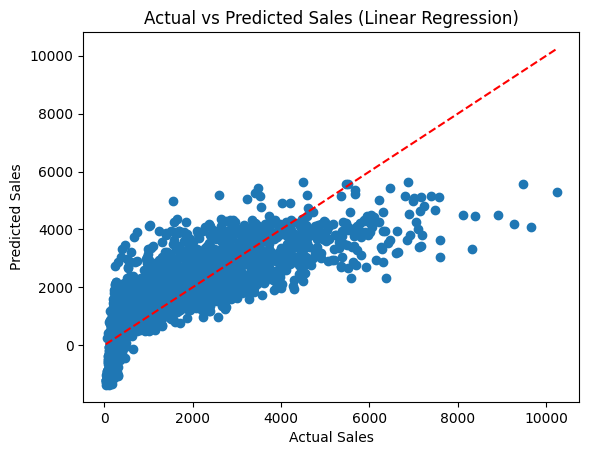

In [775]:
plt.scatter(Y_test, y1_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.show()

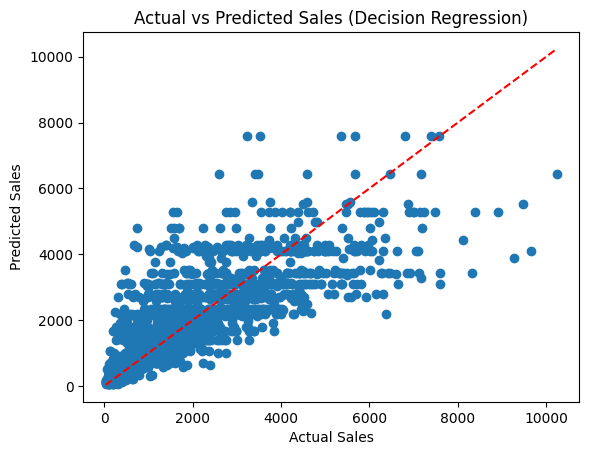

In [776]:
plt.scatter(Y_test, y2_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Decision Regression)")
plt.show()